# Observe the data and look at class imbalance

In [1]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
# reference training images folder:
train_images_folder = "Data/Training/Training_Images"

# reference csv:
train_csv = "Data/Training/Training_LabelsDemographic.csv"
# load in csv:
train_df = pd.read_csv(train_csv)

# csv columns: 'image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight', 'data_center'
print("train_csv columns: ", train_df.columns)

# head
print("train_df head: ")
print(train_df.head())

train_csv columns:  Index(['image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight',
       'data_center'],
      dtype='str')
train_df head: 
                        image  myopic_maculopathy_grade  age   sex  height  \
0  mmac_task_1_train_0001.png                         0   51  male   183.5   
1  mmac_task_1_train_0002.png                         0   51  male   183.5   
2  mmac_task_1_train_0003.png                         0   50  male   184.5   
3  mmac_task_1_train_0004.png                         0   50  male   184.5   
4  mmac_task_1_train_0005.png                         0   49  male   184.5   

   weight  data_center  
0    78.9            1  
1    78.9            1  
2    81.7            1  
3    81.7            1  
4    82.2            1  


In [3]:
# show values in myopic_maculopathy_grade
print("myopic_maculopathy_grade values: ", train_df["myopic_maculopathy_grade"].unique())
# grade 0 to 4

myopic_maculopathy_grade values:  [0 1 2 3 4]


In [4]:
# determine class imbalance (count of each grade)
print("class imbalance: ")
print(train_df["myopic_maculopathy_grade"].value_counts())

class imbalance: 
myopic_maculopathy_grade
1    412
0    404
2    224
3     60
4     43
Name: count, dtype: int64


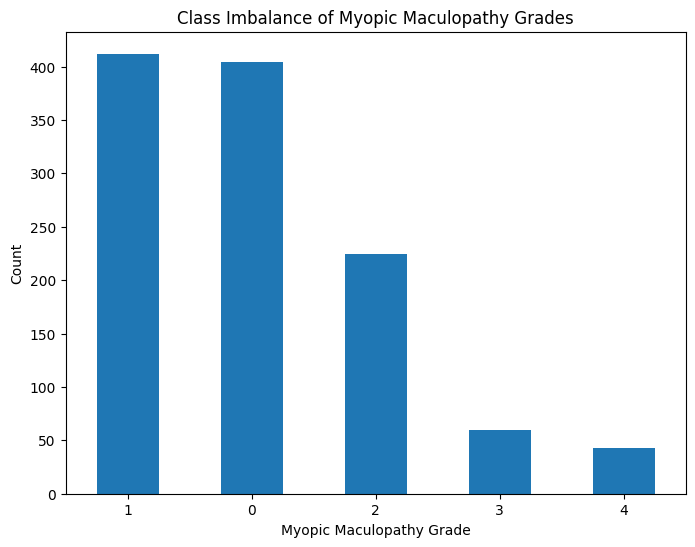

In [5]:
# bar chart of class imbalance
plt.figure(figsize=(8, 6))
train_df["myopic_maculopathy_grade"].value_counts().plot(kind="bar")
plt.title("Class Imbalance of Myopic Maculopathy Grades")
plt.xlabel("Myopic Maculopathy Grade")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Class 0 and 1 are fairly well balance - there are far less images with grade 2, 3 and 4.

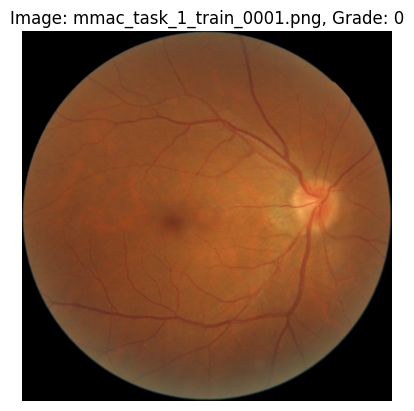

Image shape:  (800, 800)
Min pixel value:  (0, 0, 0)
Max pixel value:  (251, 163, 92)


/var/folders/q3/f8bspqwx7l54y8mwlwq7gq240000gn/T/ipykernel_52598/4050253628.py:12: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print("Min pixel value: ", min(image.getdata()))
/var/folders/q3/f8bspqwx7l54y8mwlwq7gq240000gn/T/ipykernel_52598/4050253628.py:13: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print("Max pixel value: ", max(image.getdata()))


In [6]:
# load an image and show it
image_path = os.path.join(train_images_folder, train_df["image"][0])

image = Image.open(image_path).convert("RGB") # matplotlib expects RGB, PIL loads RGBA, so we need to convert it first
plt.imshow(image)
plt.title(f"Image: {train_df['image'][0]}, Grade: {train_df['myopic_maculopathy_grade'][0]}")
plt.axis("off")
plt.show()

# print image shape and values:
print("Image shape: ", image.size)
print("Min pixel value: ", min(image.getdata()))
print("Max pixel value: ", max(image.getdata()))

# CNN classifier for myopic maculopathy:

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm


# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)


Using device: mps


In [8]:
# define a custom dataset class for loading the images and labels
class MyopicMaculopathyDataset(Dataset):
    def __init__(self, csv_file, images_folder, transform=None):
        self.data = pd.read_csv(csv_file)
        self.images_folder = images_folder
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = os.path.join(self.images_folder, self.data.iloc[idx]["image"])
        image = Image.open(img_name).convert("RGB") # RGBA to RGB
        label = self.data.iloc[idx]["myopic_maculopathy_grade"] # corresponding 0-4 label
        if self.transform:
            image = self.transform(image) # apply transform
        return image, label



In [9]:
# define transformations for the images
# convert to grayscale, normalise to [0, 1] and resize to 224x224 for ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3), # convert to grayscale but keep 3 channels to be compatible with pretrained models
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # normalise to [-1, 1]
])



In [10]:
# create dataset and dataloader
dataset = MyopicMaculopathyDataset(csv_file=train_csv, images_folder=train_images_folder, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)



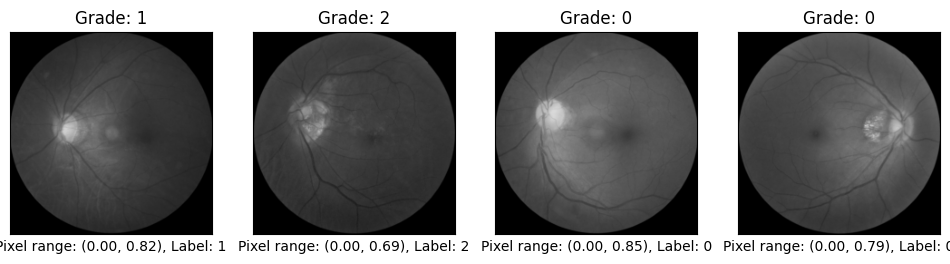

In [11]:
# visualise the transformed images
dataiter = iter(dataloader)
images, labels = next(dataiter)

# show a few transformed images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img = images[i].permute(1, 2, 0).numpy() # convert from (C, H, W) to (H, W, C) for plotting
    img = (img * 0.5) + 0.5 # un-normalise to [0, 1] for plotting
    axes[i].imshow(img)
    axes[i].set_title(f"Grade: {labels[i].item()}")

    # description:
    axes[i].set_xlabel(f"Pixel range: ({img.min():.2f}, {img.max():.2f}), Label: {labels[i].item()}")

    # no tickmarks:
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.show()



In [12]:
# now set up and train a ResNet model:
model = models.resnet18(pretrained=True) # load pretrained ResNet
# modify the final layer to output 5 classes (grades 0-4)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)

# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training loop (simplified, no validation or early stopping for now)
num_epochs = 10
# use tqdm to show progress bar:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 36/36 [00:40<00:00,  1.14s/it]


Epoch 1/10, Loss: 0.9072


Epoch 2/10: 100%|██████████| 36/36 [00:40<00:00,  1.14s/it]


Epoch 2/10, Loss: 0.7337


Epoch 3/10: 100%|██████████| 36/36 [00:41<00:00,  1.15s/it]


...

Epoch 8/10, Loss: 0.2668


Epoch 9/10: 100%|██████████| 36/36 [00:41<00:00,  1.15s/it]


Epoch 9/10, Loss: 0.1675


Epoch 10/10: 100%|██████████| 36/36 [00:41<00:00,  1.15s/it]

Epoch 10/10, Loss: 0.0997


In [13]:
# get a prediction for some values in the training set and compare to the true label:
model.eval()
with torch.no_grad():
    images, labels = next(iter(dataloader))
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    print("Predicted labels: ", preds)
    print("True labels: ", labels)

Predicted labels:  tensor([0, 4, 1, 1, 1, 2, 1, 2, 0, 1, 0, 4, 0, 1, 1, 2, 0, 1, 2, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 1, 0, 1, 0])
True labels:  tensor([0, 4, 1, 1, 1, 2, 1, 2, 0, 1, 0, 3, 0, 1, 1, 2, 0, 2, 2, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 1, 0, 1, 0])
